# Laboratory Task 3 (01_Understanding Deep Learning)

<div style="background-color: #d4e7d4; padding: 20px; border-radius: 8px; color: #2e4d2e; margin-bottom: 20px;">
  <p style="margin:0; font-size: 1.1em;"><strong>Course:</strong> DS Elective 4 - Deep Learning</p>
  <p style="margin:0; font-size: 1.1em;"><strong>Name:</strong> Gem Nicole R. Diones</p>
  <p style="margin:0; font-size: 1.1em;"><strong>Year & Section:</strong> DS4A</p>
</div>

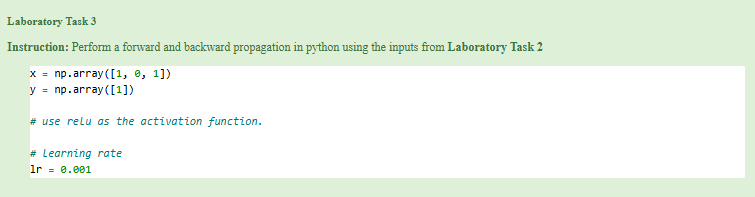

### Imports & Activation Functions

In [ ]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

### Parameter Initialization

In [ ]:
# Input vector
x = np.array([[1], [0], [1]])

# Hidden unit weights
hidden_weights = np.array([
    [0.2, -0.3],
    [0.4,  0.1],
    [-0.5, 0.2]
])

# Output unit weights
output_weights = np.array([
    [-0.3],
    [-0.2]
])

# Bias
hidden_bias = np.array([[-0.4], [0.2]])
output_bias = np.array([[0.1]])

# True target value
target = np.array([[1]])

# Learning rate
lr = 0.001

### Forward Propagation

In [ ]:
# Calculate hidden layer weighted sum
hidden_sum = hidden_weights.T @ x + hidden_bias

# Activate hidden layer neurons
hidden_output = relu(hidden_sum)

# Calculate output layer weighted sum
output_sum = output_weights.T @ hidden_output + output_bias

# Get final prediction
prediction = relu(output_sum)
print(f"Final Prediction: {prediction.flatten()[0]:.4f}\n")

Final Prediction: 0.0800



### Backward Propagation

In [ ]:
# Calculate error derivative
error_derivative = -(target - prediction)

# Backpropagate to output layer
delta_output = error_derivative * relu_derivative(output_sum)
print(f"Delta for output layer (delta_output):\n{delta_output}\n")

# Calculate derivative of error wrt output weights
d_output_weights = delta_output @ hidden_output.T
print(f"Derivative of error wrt output weights (d_output_weights):\n{d_output_weights}\n")

# Backpropagate to hidden layer
delta_hidden = (output_weights @ delta_output) * relu_derivative(hidden_sum)
print(f"Delta for hidden layer (delta_hidden):\n{delta_hidden}\n")

# Calculate derivative of error wrt hidden weights
d_hidden_weights = delta_hidden @ x.T
print(f"Derivative of error wrt hidden weights (d_hidden_weights):\n{d_hidden_weights}\n")

Delta for output layer (delta_output):
[[-0.92]]

Derivative of error wrt output weights (d_output_weights):
[[ 0.    -0.092]]

Delta for hidden layer (delta_hidden):
[[0.   ]
 [0.184]]

Derivative of error wrt hidden weights (d_hidden_weights):
[[0.    0.    0.   ]
 [0.184 0.    0.184]]



### Weight Updates

In [ ]:
# Update output layer weights and bias
output_weights -= lr * d_output_weights.T
output_bias -= lr * delta_output
print(f"Updated Output Weights (output_weights):\n{output_weights}\n")

# Update hidden layer weights and bias
hidden_weights -= lr * d_hidden_weights.T
hidden_bias -= lr * delta_hidden
print(f"Updated Hidden Weights (hidden_weights):\n{hidden_weights}\n")

Updated Output Weights (output_weights):
[[-0.3     ]
 [-0.199908]]

Updated Hidden Weights (hidden_weights):
[[ 0.2      -0.300184]
 [ 0.4       0.1     ]
 [-0.5       0.199816]]



### Conclusion

In this laboratory, we successfully implemented a complete training cycle for a simple neural network. The process commenced with **forward propagation**, where the initial inputs were passed through the hidden and output layers to generate a final prediction of **0.0800**.

Subsequently, we initiated **backward propagation** by first calculating the error between this prediction and the true target value. This error signal was then propagated backward through the network, allowing us to compute the gradients or the contribution of each weight and bias to the total error using the chain rule. These gradients indicated the direction and magnitude of change required for each parameter to improve the model’s performance.

The final step was the **parameter update**, where we adjusted the network’s weights and biases in the opposite direction of their respective gradients, scaled by a small learning rate. This single, complete iteration demonstrates the fundamental mechanism by which a neural network learns, incrementally refining its parameters to minimize prediction error.